In [ ]:
from google.colab import files
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import matplotlib.pyplot as plt

In [ ]:
upload = files.upload()

Saving battery_synthetic_dataset.csv to battery_synthetic_dataset.csv


In [ ]:
df = pd.read_csv("battery_synthetic_dataset.csv")

In [ ]:
df.head()

,avg_voltage,avg_temperature,battery_life_months,cycle_count,label
0,3.327,39.19,61.5,1127,0
1,3.419,34.96,40.8,861,0
2,3.456,44.52,59.3,1131,0
3,3.292,39.37,49.5,1096,0
4,3.196,35.65,48.1,1045,0


In [ ]:
print(df.shape)

(1000, 5)


In [ ]:
print(df.columns)

Index(['avg_voltage', 'avg_temperature', 'battery_life_months', 'cycle_count',
       'label'],
      dtype='object')


In [ ]:
data = df.copy()

In [ ]:
x = data.drop("label", axis=1)
y = data["label"]

In [ ]:
print(x.shape)
print(y.shape)
print(y.value_counts())

(1000, 4)
(1000,)
label
1    639
0    361
Name: count, dtype: int64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
input_size = x_train.shape[1]
hidden_size = 10
output_size = 1

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    return x * (1 - x)
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return (x > 0).astype(float)

In [ ]:
rng = np.random.default_rng(42)

def he_init(fan_in, fan_out):
    return rng.standard_normal((fan_in, fan_out)) * np.sqrt(2 / fan_in)

In [ ]:
weight_input_hidden = he_init(input_size, hidden_size)
bias_input_hidden = np.zeros((1, hidden_size))

weight_hidden_output = he_init(hidden_size, output_size)
bias_hidden_output = np.zeros((1, output_size))

In [ ]:
epochs = 10000
learning_rate = 1e-2
n = x_train.shape[0]

In [ ]:
loss_history = []
for epoch in range(epochs):
  input_data = x_train

  # Forward pass
  hidden_input = np.dot(input_data,weight_input_hidden) + bias_input_hidden
  hidden_output = relu(hidden_input)

  output_input = np.dot(hidden_output,weight_hidden_output) + bias_hidden_output
  output = sigmoid(output_input)

  # Calculate error
  error = y_train.values.reshape(-1, 1) - output
  # Backpropagation
  delta_output = error * sigmoid_derivative(output)
  delta_hidden = (delta_output.dot(weight_hidden_output.T)* relu_derivative(hidden_input))

  # Gradients
  gradient_hidden_output = (hidden_output.T.dot(delta_output) / n)
  gradient_input_hidden = (input_data.T.dot(delta_hidden) / n)

  # Update biases
  bias_hidden_output += (learning_rate* np.mean(delta_output, axis=0, keepdims=True))

  # Update weights
  weight_hidden_output += (learning_rate * gradient_hidden_output)

  # Calculate loss
  loss = np.mean(np.square(error))
  loss_history.append(loss)

  # Display training progress
  if (epoch + 1) % 1000 == 0 or epoch == 0:
      print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss:.6f}")


Epoch 1/10000 - Loss: 0.332588
Epoch 1000/10000 - Loss: 0.138474
Epoch 2000/10000 - Loss: 0.107823
Epoch 3000/10000 - Loss: 0.094968
Epoch 4000/10000 - Loss: 0.088037
Epoch 5000/10000 - Loss: 0.083735
Epoch 6000/10000 - Loss: 0.080813
Epoch 7000/10000 - Loss: 0.078701
Epoch 8000/10000 - Loss: 0.077106
Epoch 9000/10000 - Loss: 0.075858
Epoch 10000/10000 - Loss: 0.074856


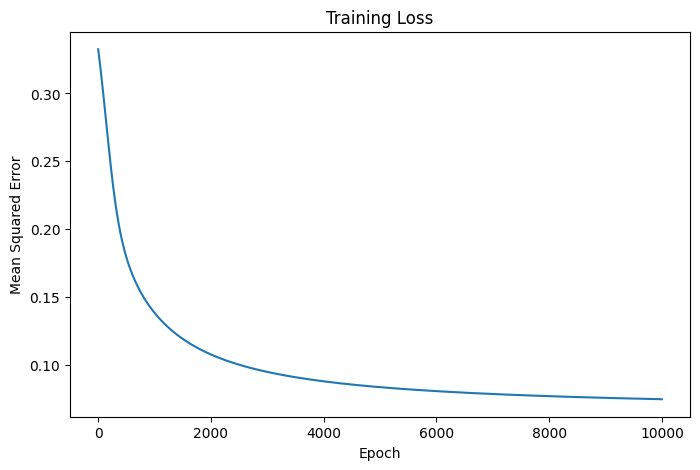

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss")

plt.show()

In [ ]:
hidden_input_test = (np.dot(x_test, weight_input_hidden)+ bias_input_hidden)

hidden_output_test = relu(hidden_input_test)

output_input_test = (np.dot(hidden_output_test, weight_hidden_output)+ bias_hidden_output)

test_probability = sigmoid(output_input_test)

In [ ]:
predicted_labels = (test_probability > 0.5).astype(int).ravel()

In [ ]:
## Evaluate

In [ ]:
accuracy = accuracy_score(y_test, predicted_labels)
print("Accuracy:", accuracy)

Accuracy: 0.91


In [ ]:
precision = precision_score(y_test,predicted_labels,zero_division=0)
print("Precision:", precision)

Precision: 0.9583333333333334


In [ ]:
recall = recall_score(y_test,predicted_labels,zero_division=0)
print("Recall:", recall)

Recall: 0.8984375


In [ ]:
f1 = f1_score(y_test,predicted_labels,zero_division=0)
print("F1-score:", f1)

F1-score: 0.9274193548387096


In [ ]:
print(classification_report(y_test,predicted_labels,zero_division=0))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88        72
           1       0.96      0.90      0.93       128

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



In [ ]:
cm = confusion_matrix(y_test, predicted_labels)
print(cm)

[[ 67   5]
 [ 13 115]]


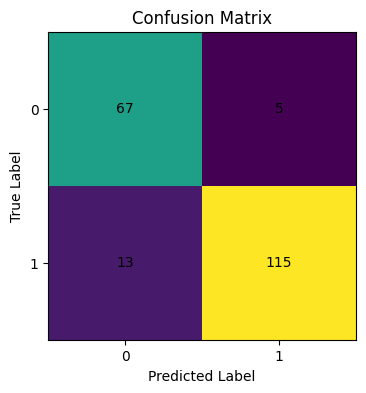

In [ ]:
plt.figure(figsize=(5, 4))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()